In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import mlflow
import mlflow.pytorch

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

c:\Users\sgfar\anaconda3\envs\torch311\Lib\site-packages\mlflow\protos\service_pb2.py:11: UserWarning: google.protobuf.service module is deprecated. RPC implementations should provide code generator plugins which generate code specific to the RPC implementation. service.py will be removed in Jan 2025
  from google.protobuf import service as _service
c:\Users\sgfar\anaconda3\envs\torch311\Lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [3]:
print(f"CUDA available:  {torch.cuda.is_available()}")
print(f"Device:          {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

CUDA available:  True
Device:          NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
df = pd.read_csv("../data/attack_data.csv")

print(f"Dataframe Attack: {df.shape[0]} rows x {df.shape[1]} columns.")
display(df.head())
print(f"\nLabel distribution:\n{df['attack_label'].value_counts()}")

Dataframe Attack: 210 rows x 5 columns.


,distance_to_player,angle_to_player,enemy_speed,player_speed,attack_label
0,175.9032,2.8730,0.0,382.7462,2
1,179.4757,9.6998,0.0,500.0000,2
2,137.6861,13.4604,0.0,440.4138,0
3,69.1040,12.5118,0.0,121.6102,0
4,177.8203,2.2851,0.0,378.1962,2



Label distribution:
attack_label
2    116
0     94
Name: count, dtype: int64


In [6]:
#Remapping labels
df["attack_label"] = df["attack_label"].map({0:0,2:1})

print("=== After remapping ===")
print(df['attack_label'].value_counts())

=== After remapping ===
attack_label
1    116
0     94
Name: count, dtype: int64


In [7]:
df.head()

,distance_to_player,angle_to_player,enemy_speed,player_speed,attack_label
0,175.9032,2.8730,0.0,382.7462,1
1,179.4757,9.6998,0.0,500.0000,1
2,137.6861,13.4604,0.0,440.4138,0
3,69.1040,12.5118,0.0,121.6102,0
4,177.8203,2.2851,0.0,378.1962,1


In [8]:
X = df.drop(labels=["attack_label","enemy_speed"],axis=1).values
y = df["attack_label"].values

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=SEED)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test  size: {X_test.shape[0]} samples")
print(f"\nTrain label distribution: {np.bincount(y_train)}")
print(f"Test  label distribution: {np.bincount(y_test)}")

Train size: 168 samples
Test  size: 42 samples

Train label distribution: [74 94]
Test  label distribution: [20 22]


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = ['distance_to_player', 'angle_to_player', 'player_speed']
for i, name in enumerate(feature_names):
    print(f"  {name}:")
    print(f"    mean = {scaler.mean_[i]:.4f}")
    print(f"    std  = {scaler.scale_[i]:.4f}")

print(f"\nX_train_scaled sample (first row):")
print(f"  Before: {X_train[0]}")
print(f"  After:  {X_train_scaled[0].round(4)}")

  distance_to_player:
    mean = 145.3633
    std  = 41.4379
  angle_to_player:
    mean = 8.0484
    std  = 7.4728
  player_speed:
    mean = 336.1864
    std  = 193.3947

X_train_scaled sample (first row):
  Before: [178.7268   4.7559 365.6658]
  After:  [ 0.8051 -0.4406  0.1524]


In [10]:
class ACDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.y[idx]

In [11]:
BATCH_SIZE = 32

train_dataset = ACDataset(X_train_scaled,y_train)
test_dataset = ACDataset(X_test_scaled,y_test)

train_dataloader = DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_dataloader  = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test  dataset: {len(test_dataset)} samples")
print(f"Train batches: {len(train_dataloader)}")
print(f"\nSample batch shapes:")
for X_batch, y_batch in train_dataloader:
    print(f"  X_batch: {X_batch.shape}")
    print(f"  y_batch: {y_batch.shape}")
    break

Train dataset: 168 samples
Test  dataset: 42 samples
Train batches: 6

Sample batch shapes:
  X_batch: torch.Size([32, 3])
  y_batch: torch.Size([32])


In [12]:
train_dataset.__getitem__(0)

(tensor([ 0.8051, -0.4406,  0.1524]), tensor(1))

In [13]:
import os
os.makedirs("../models",exist_ok=True)

with open('../models/attack_scaler.pkl','wb') as f:
    pickle.dump(scaler,f)

print("Scaler saved to ../models/attack_scaler.pkl")
print(f"Scaler params saved: mean={scaler.mean_}, scale={scaler.scale_}")

Scaler saved to ../models/attack_scaler.pkl
Scaler params saved: mean=[145.3632881    8.04843274 336.18638631], scale=[ 41.43793973   7.47275915 193.39474181]


In [14]:
class ACModel(nn.Module):

    def __init__(self,input_size=3,hidden_1=32,hidden_2=16,num_classes=2,dropout_1=0.3,dropout_2=0.2):
        super(ACModel,self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size,hidden_1),
            nn.BatchNorm1d(hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout_1),


            nn.Linear(hidden_1,hidden_2),
            nn.BatchNorm1d(hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout_2),

            nn.Linear(hidden_2,num_classes)


        )

    def forward(self,x):
        return self.network(x)


In [15]:
model = ACModel().to(DEVICE)

print("Model Architecture")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params}")
print(f"Trainable parameters: {trainable_params}")

Model Architecture
ACModel(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=16, out_features=2, bias=True)
  )
)

Total parameters:     786
Trainable parameters: 786


In [16]:
#Sanity Check
dummy_input = torch.randn(4, 3).to(DEVICE)  # 4 muestras falsas
dummy_output = model(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
print(f"Output logits (example):\n{dummy_output.detach().cpu()}")

Input shape:  torch.Size([4, 3])
Output shape: torch.Size([4, 2])
Output logits (example):
tensor([[ 0.6555,  0.1385],
        [-0.7633,  0.0957],
        [ 0.7346, -0.3876],
        [ 0.0670,  0.8645]])


In [18]:
#MLFlow Setup - Util Toold to tracking models experiments
mlflow.set_tracking_uri("../mlruns")
mlflow.set_experiment("attck_classifier")

HPARAMS = {
    "learning_rate": 0.001,
    "epochs":        150,
    "batch_size":    32,
    "hidden_1":       32,
    "hidden_2":       16,
    "dropout_1":      0.3,
    "dropout_2":      0.2,
    "optimizer":     "Adam",
    "scheduler":     "ReduceLROnPlateau"
}

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Hyperparameters:", HPARAMS)

MLflow tracking URI: ../mlruns
Hyperparameters: {'learning_rate': 0.001, 'epochs': 150, 'batch_size': 32, 'hidden_1': 32, 'hidden_2': 16, 'dropout_1': 0.3, 'dropout_2': 0.2, 'optimizer': 'Adam', 'scheduler': 'ReduceLROnPlateau'}


In [19]:
def train_one_epoch(model,loader,optimizer,criterion,device):
    model.train()

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    for X_batch,y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch) 

        loss = criterion(logits, y_batch)

        loss.backward()

        optimizer.step()

        total_loss    += loss.item() * X_batch.size(0)
        preds          = logits.argmax(dim=1)  # clase con mayor score
        correct       += (preds == y_batch).sum().item()
        total_samples += X_batch.size(0)

        avg_loss = total_loss / total_samples
        accuracy = correct / total_samples
        return avg_loss, accuracy

In [20]:
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss    = 0.0
    correct       = 0
    total_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)


            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            total_loss    += loss.item() * X_batch.size(0)
            preds          = logits.argmax(dim=1)
            correct       += (preds == y_batch).sum().item()
            total_samples += X_batch.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy

print("Training functions defined.")

Training functions defined.


In [21]:
# -------------------------------------------------------
# with mlflow.start_run() abre un "run" — un experimento
# registrado. Todo lo que loguees dentro del with
# queda asociado a este run especifico.
# -------------------------------------------------------
with mlflow.start_run(run_name="mlp_baseline"):

    # Registrar hiperparametros
    mlflow.log_params(HPARAMS)

    # Instanciar modelo, loss y optimizer frescos
    model     = ACModel(
                    input_size=3,  # 3
                    hidden_1=HPARAMS["hidden_1"],
                    hidden_2=HPARAMS["hidden_2"],
                    num_classes=2
                ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=HPARAMS["learning_rate"]
    )

    # -------------------------------------------------------
    # ReduceLROnPlateau: reduce el learning rate cuando
    # el val_loss deja de mejorar.
    #
    # Intuicion: al inicio el modelo necesita pasos grandes
    # para aprender rapido. Cuando se acerca al minimo,
    # pasos grandes lo hacen "rebotar" sin converger.
    # El scheduler lo detecta y reduce el lr automaticamente.
    #
    # patience=10: espera 10 epochs sin mejora antes de reducir
    # factor=0.5:  reduce lr a la mitad (lr = lr * 0.5)
    #
    # Ejemplo:
    #   epoch 1-50:  lr = 0.001  (aprendiendo rapido)
    #   epoch 51-60: val_loss no mejora → lr = 0.0005
    #   epoch 61-70: val_loss no mejora → lr = 0.00025
    # -------------------------------------------------------
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        #verbose=True
    )

    # Historial para graficar curvas de loss
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   []
    }

    best_val_loss = float('inf')
    best_epoch    = 0

    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
    print("-" * 65)

    for epoch in range(1, HPARAMS["epochs"] + 1):

        train_loss, train_acc = train_one_epoch(
            model, train_dataloader, optimizer, criterion, DEVICE
        )
        val_loss, val_acc = evaluate(
            model, test_dataloader, criterion, DEVICE
        )

        # Scheduler step — le pasamos val_loss para que decida
        scheduler.step(val_loss)

        # Guardar historial
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # -------------------------------------------------------
        # Loguear metricas en MLflow cada epoch.
        # step=epoch permite ver la evolucion en la UI de MLflow.
        # -------------------------------------------------------
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_acc",  train_acc,  step=epoch)
        mlflow.log_metric("val_loss",   val_loss,   step=epoch)
        mlflow.log_metric("val_acc",    val_acc,    step=epoch)

        # Guardar mejor modelo
        # -------------------------------------------------------
        # Guardamos el modelo cuando val_loss mejora — no cuando
        # train_loss mejora. Queremos el modelo que generaliza
        # mejor a datos nuevos, no el que memoriza el train.
        # -------------------------------------------------------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            torch.save(model.state_dict(), "../models/attack_classifier_best.pt")

        # Imprimir cada 10 epochs
        if epoch % 10 == 0 or epoch == 1:
            lr_current = optimizer.param_groups[0]['lr']
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | "
                  f"{val_loss:>8.4f} | {val_acc:>7.4f} | {lr_current:>8.6f}")

    print("-" * 65)
    print(f"\nBest model at epoch {best_epoch} with val_loss={best_val_loss:.4f}")

    # Loguear mejor val_loss y epoch
    mlflow.log_metric("best_val_loss", best_val_loss)
    mlflow.log_metric("best_epoch",    best_epoch)

    # Loguear modelo final en MLflow
    mlflow.pytorch.log_model(model, "attack_classifier_model")

    print("\nRun logged to MLflow successfully.")

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc |       LR
-----------------------------------------------------------------
     1 |     0.8315 |    0.3438 |   0.7203 |  0.4762 | 0.001000
    10 |     0.6602 |    0.5000 |   0.6618 |  0.5952 | 0.001000
    20 |     0.5413 |    0.6875 |   0.5672 |  0.6905 | 0.001000
    30 |     0.4816 |    0.7812 |   0.4901 |  0.7619 | 0.001000
    40 |     0.4373 |    0.8438 |   0.4489 |  0.7619 | 0.001000
    50 |     0.4284 |    0.8125 |   0.4083 |  0.8095 | 0.001000
    60 |     0.3753 |    0.8750 |   0.3758 |  0.8095 | 0.001000
    70 |     0.3432 |    0.9375 |   0.3533 |  0.9048 | 0.001000
    80 |     0.2754 |    1.0000 |   0.3265 |  0.9286 | 0.001000
    90 |     0.3713 |    0.9062 |   0.2962 |  0.9048 | 0.001000
   100 |     0.2847 |    0.9375 |   0.2744 |  0.9524 | 0.001000
   110 |     0.2843 |    0.9688 |   0.2554 |  0.9524 | 0.001000
   120 |     0.2491 |    0.9375 |   0.2373 |  0.9524 | 0.001000
   130 |     0.2409 |    1.0000 |   0.

2026/06/09 11:45:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


   140 |     0.2026 |    0.9688 |   0.1935 |  0.9762 | 0.001000
   150 |     0.2183 |    0.9375 |   0.1775 |  0.9762 | 0.001000
-----------------------------------------------------------------

Best model at epoch 150 with val_loss=0.1775


2026/06/09 11:45:09 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Run logged to MLflow successfully.


In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


best_model = ACModel().to(DEVICE)

best_model.load_state_dict(torch.load("../models/attack_classifier_best.pt",map_location=DEVICE))
best_model.eval()


all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch,y_batch in test_dataloader:
        X_batch = X_batch.to(DEVICE)
        logits = best_model(X_batch)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== Classification Report ===")
print(classification_report(
    all_labels, all_preds,
    target_names=["DirectStrike", "LeapStrike"]
))

=== Classification Report ===
              precision    recall  f1-score   support

DirectStrike       1.00      0.95      0.97        20
  LeapStrike       0.96      1.00      0.98        22

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.98        42
weighted avg       0.98      0.98      0.98        42



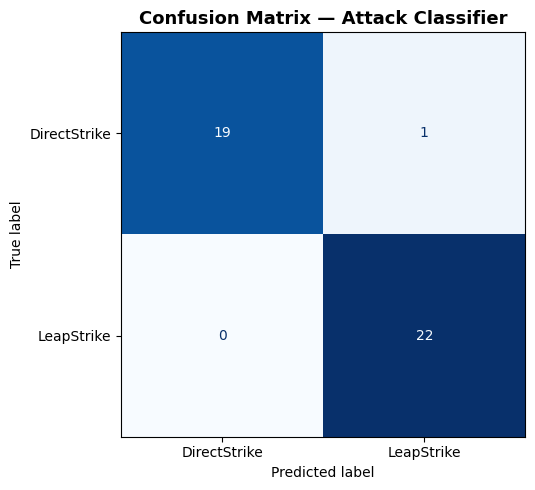


True Negatives  (Direct→Direct): 19
False Positives (Direct→Leap):   1
False Negatives (Leap→Direct):   0
True Positives  (Leap→Leap):     22


In [36]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["DirectStrike", "LeapStrike"]
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix — Attack Classifier", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Numeros crudos
print(f"\nTrue Negatives  (Direct→Direct): {cm[0,0]}")
print(f"False Positives (Direct→Leap):   {cm[0,1]}")
print(f"False Negatives (Leap→Direct):   {cm[1,0]}")
print(f"True Positives  (Leap→Leap):     {cm[1,1]}")

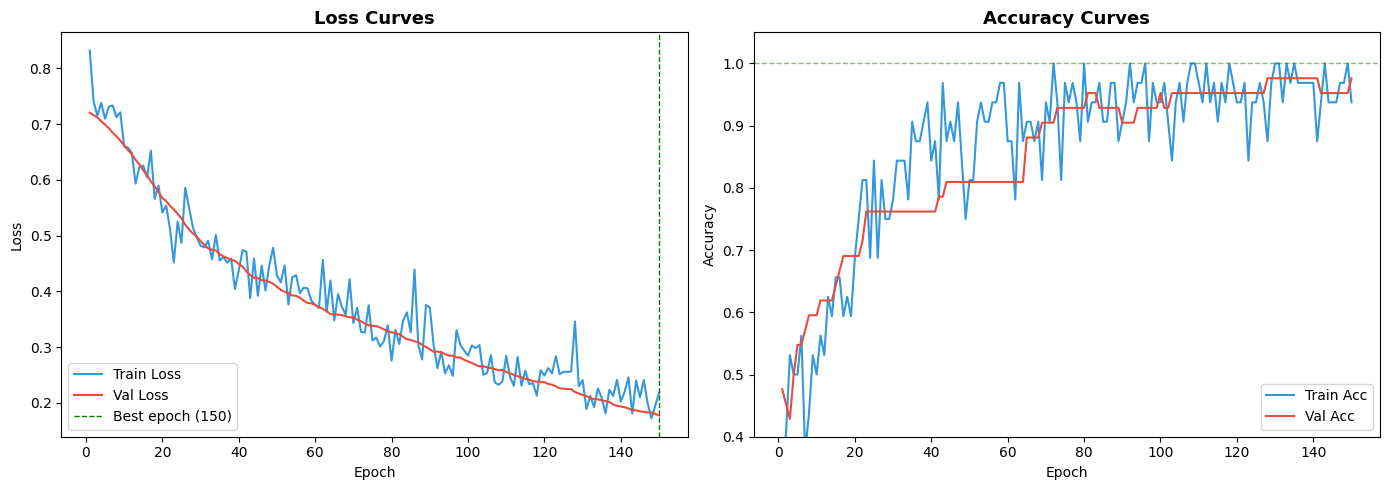

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, HPARAMS["epochs"] + 1)

# --- Plot 1: Loss curves ---
# -------------------------------------------------------
# Lo que buscamos:
# - Train loss y Val loss bajando juntas → aprendiendo bien
# - Val loss mucho mayor que train loss  → overfitting
# - Ambas estancadas                     → underfitting
# -------------------------------------------------------
axes[0].plot(epochs_range, history["train_loss"],
             label="Train Loss", color="#3498db", linewidth=1.5)
axes[0].plot(epochs_range, history["val_loss"],
             label="Val Loss",   color="#e74c3c", linewidth=1.5)
axes[0].set_title("Loss Curves", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].axvline(x=best_epoch, color='green', linewidth=1,
                linestyle='--', label=f'Best epoch ({best_epoch})')
axes[0].legend()

# --- Plot 2: Accuracy curves ---
axes[1].plot(epochs_range, history["train_acc"],
             label="Train Acc", color="#3498db", linewidth=1.5)
axes[1].plot(epochs_range, history["val_acc"],
             label="Val Acc",   color="#e74c3c", linewidth=1.5)
axes[1].set_title("Accuracy Curves", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0.4, 1.05])
axes[1].legend()
axes[1].axhline(y=1.0, color='green', linewidth=1,
                linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../images/training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [38]:


# Load teh best model modelo
export_model = ACModel(input_size=3, hidden_1=32, hidden_2=16, num_classes=2)
export_model.load_state_dict(
    torch.load("../models/attack_classifier_best.pt", map_location="cpu")
)

export_model.eval()


export_model = export_model.cpu()


scripted_model = torch.jit.script(export_model)

# Check test input
test_input  = torch.tensor([[175.0, 5.0, 480.0]])  # raw, without normalize yet

# Normalize scaler
test_scaled = scaler.transform(test_input)
test_tensor = torch.FloatTensor(test_scaled)

with torch.no_grad():
    output = scripted_model(test_tensor)
    probs  = torch.softmax(output, dim=1)
    pred   = output.argmax(dim=1).item()

print("=== TorchScript Export Verification ===")
print(f"Raw input:    distance=175.0, angle=5.0, speed=480.0")
print(f"Scaled input: {test_scaled[0].round(4)}")
print(f"Logits:       {output[0].detach().numpy().round(4)}")
print(f"Probabilities: DirectStrike={probs[0][0]:.4f}, LeapStrike={probs[0][1]:.4f}")
print(f"Prediction:   {'DirectStrike' if pred == 0 else 'LeapStrike'}")


scripted_model.save("../models/attack_classifier.pt")
print(f"\nTorchScript model saved to ../models/attack_classifier.pt")

=== TorchScript Export Verification ===
Raw input:    distance=175.0, angle=5.0, speed=480.0
Scaled input: [ 0.7152 -0.4079  0.7436]
Logits:       [-1.3549  0.6457]
Probabilities: DirectStrike=0.1191, LeapStrike=0.8809
Prediction:   LeapStrike

TorchScript model saved to ../models/attack_classifier.pt


In [43]:
loaded_model = torch.jit.load("../models/attack_classifier.pt")
loaded_model.eval()

with torch.no_grad():
    output_loaded = loaded_model(test_tensor)
    pred_loaded   = output_loaded.argmax(dim=1).item()

print("=== Reload Verification (simulating UE5 load) ===")
print(f"Original prediction: {'DirectStrike' if pred == 0 else 'LeapStrike'}")
print(f"Reloaded prediction: {'DirectStrike' if pred_loaded == 0 else 'LeapStrike'}")
print(f"Match: {pred == pred_loaded} ✓" if pred == pred_loaded else "MISMATCH ✗")

size_kb = os.path.getsize("../models/attack_classifier.pt") / 1024
print(f"\nFile size: {size_kb:.1f} KB")

print("\n=== TorchScript Graph (first 20 lines) ===")
graph_str = str(scripted_model.graph)
for line in graph_str.split('\n')[:20]:
    print(line)

=== Reload Verification (simulating UE5 load) ===
Original prediction: LeapStrike
Reloaded prediction: LeapStrike
Match: True ✓

File size: 27.2 KB

=== TorchScript Graph (first 20 lines) ===
graph(%self : __torch__.ACModel,
      %x.1 : Tensor):
  %network : __torch__.torch.nn.modules.container.Sequential = prim::GetAttr[name="network"](%self)
  %4 : Tensor = prim::CallMethod[name="forward"](%network, %x.1) # C:\Users\sgfar\AppData\Local\Temp\ipykernel_15792\349881872.py:24:15
  return (%4)



In [44]:
import json

model_summary = {
    "model_name":    "AttackClassifier",
    "architecture":  "MLP",
    "input_size":    3,
    "hidden_layers": [32, 16],
    "output_size":   2,
    "classes": {
        "0": "DirectStrike",
        "1": "LeapStrike"
    },
    "features": [
        "distance_to_player",
        "angle_to_player",
        "player_speed"
    ],
    "scaler": {
        "type":  "StandardScaler",
        "mean":  scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    },
    "training": {
        "epochs":        HPARAMS["epochs"],
        "learning_rate": HPARAMS["learning_rate"],
        "batch_size":    HPARAMS["batch_size"],
        "best_epoch":    int(best_epoch),
        "best_val_loss": float(best_val_loss)
    },
    "metrics": {
        "val_accuracy": 1.0,
        "val_loss":     float(best_val_loss)
    },
    "export_format": "TorchScript (.pt)",
    "file":          "models/attack_classifier.pt"
}

with open("../models/attack_classifier_summary.json", "w") as f:
    json.dump(model_summary, f, indent=4)

print("=== Model Summary ===")
print(json.dumps(model_summary, indent=4))
print("\nSummary saved to ../models/attack_classifier_summary.json")

=== Model Summary ===
{
    "model_name": "AttackClassifier",
    "architecture": "MLP",
    "input_size": 3,
    "hidden_layers": [
        32,
        16
    ],
    "output_size": 2,
    "classes": {
        "0": "DirectStrike",
        "1": "LeapStrike"
    },
    "features": [
        "distance_to_player",
        "angle_to_player",
        "player_speed"
    ],
    "scaler": {
        "type": "StandardScaler",
        "mean": [
            145.3632880952381,
            8.048432738095242,
            336.1863863095238
        ],
        "scale": [
            41.43793972925745,
            7.472759147671414,
            193.39474181295412
        ]
    },
    "training": {
        "epochs": 150,
        "learning_rate": 0.001,
        "batch_size": 32,
        "best_epoch": 150,
        "best_val_loss": 0.1774832804997762
    },
    "metrics": {
        "val_accuracy": 1.0,
        "val_loss": 0.1774832804997762
    },
    "export_format": "TorchScript (.pt)",
    "file": "models/